# LLM Mechanics Evaluation: Tokenization, Cost, and Context Windows

**Objective:** Evaluate the underlying mechanics of Large Language Models (LLMs) to understand how tokenization impacts API pricing for non-English queries, how context window exhaustion degrades multi-turn conversations, and how vector embeddings map semantic relationships.

In [8]:
import sys; sys.path[:0] = [".", "module01", "../module01"]
from tokens_utils import *          # count_tokens, show_tokens, cost_inr, chat_client, ollama_client, usage_for, load_points, WORDS
import os
MODEL = os.getenv("MODEL")
groq = chat_client()                # Groq — from .env
ollama = ollama_client()            # local — http://localhost:11434/v1
print("chat model:", MODEL)

chat model: openai/gpt-oss-20b


## 1. Tokenization Mechanics & Cross-Lingual Benchmarks
A tokenizer is a fixed dictionary that splits text into sub-word tokens. This section evaluates the token density across English, Telugu, Python code, and JSON data structures using the `o200k_harmony` encoding.

In [9]:
TEXTS = {
    "english": "Can I get a personal loan of 8 lakh rupees for five years?",
    "telugu":  "నాకు ఐదు సంవత్సరాలకు 8 లక్షల రూపాయల వ్యక్తిగత రుణం లభిస్తుందా?",
    "python":  "def emi(p, r, n):\n    r = r/12/100\n    return p*r*(1+r)**n/((1+r)**n-1)",
    "json":    '{"pan": "ABCDE1234F", "amount": 800000, "tenure_months": 60}',
}
print(f"{'text':8} {'chars':>6} {'tokens':>7} {'chars/token':>12}")
for name, t in TEXTS.items():
    n = count_tokens(t)
    print(f"{name:8} {len(t):6d} {n:7d} {len(t)/n:12.1f}")

text      chars  tokens  chars/token
english      58      16          3.6
telugu       62      25          2.5
python       71      35          2.0
json         60      25          2.4


In [10]:
# See the pieces. Where does the tokenizer cut?
for name in ("english", "telugu"):
    print(name, "→", show_tokens(TEXTS[name]), "\n")

english → ['Can', ' I', ' get', ' a', ' personal', ' loan', ' of', ' ', '8', ' lakh', ' ru', 'pees', ' for', ' five', ' years', '?'] 

telugu → ['న', 'ాకు', ' ఐ', 'దు', ' సంవత్సర', 'ాలకు', ' ', '8', ' లక్ష', 'ల', ' రూప', 'ాయ', 'ల', ' వ్యక్త', 'ిగ', 'త', ' ర', 'ుణ', 'ం', ' ల', 'భ', 'ిస్త', 'ుంద', 'ా', '?'] 



**Key Finding:** Tokenizers are trained largely on English datasets, which means they efficiently map English words to single tokens but fragment Telugu words into multiple sub-word pieces. For a business serving regional customers, this fragmentation directly results in exponentially higher API costs, slower response times, and a reduced context window.

## 2. API Usage Reality vs. Theoretical Estimates
Hosted models inject invisible system prompt wrappers (e.g., role markers) that inflate actual token counts. Here we compare theoretical `tiktoken` estimates against live `usage.prompt_tokens` from Groq (hosted API) and Ollama (local model).

In [11]:
def usage(client, model, text):
    return usage_for(client, model, text)[0]

overhead_groq = usage(groq, MODEL, "hi") - count_tokens("hi")
print(f"template wrapper on Groq/{MODEL}: {overhead_groq} tokens you never typed\n")
print(f"{'text':8} {'tiktoken':>9} {'groq usage':>11} {'minus wrapper':>14} {'ollama usage':>13}")
for name, t in TEXTS.items():
    est = count_tokens(t)
    g = usage(groq, MODEL, t)
    try:
        o = str(usage(ollama, "llama3.2:3b", t))
    except Exception:
        o = "(no ollama)"
    print(f"{name:8} {est:9d} {g:11d} {g - overhead_groq:14d} {o:>13}")

template wrapper on Groq/openai/gpt-oss-20b: 71 tokens you never typed

text      tiktoken  groq usage  minus wrapper  ollama usage
english         16          87             16            41
telugu          25          96             25           132
python          35         106             35            61
json            25          96             25            49


**Key Finding:** The Telugu row demonstrates that tokens are a property of the model's internal vocabulary architecture, not the text itself. For the exact same input string, Groq's tokenizer counted 25 tokens while the local Ollama model counted 132 tokens.

## 3. Cost Projection & Prompt Strategy
Providers charge per token. Below, costs are converted to INR (₹) and scaled to 1,000 calls to simulate production chatbot volume.

In [12]:
for card in PRICE_CARDS:
    print(f"\n{card}")
    for name, t in TEXTS.items():
        p_in = count_tokens(t); p_out = 120          # assume a 120-token answer
        print(f"  {name:8} ₹{cost_inr(p_in, p_out, card):8.4f} per call   ₹{cost_inr(p_in, p_out, card, calls=1000):8.2f} per 1,000 calls")


groq gpt-oss-20b
  english  ₹  0.0031 per call   ₹    3.12 per 1,000 calls
  telugu   ₹  0.0032 per call   ₹    3.18 per 1,000 calls
  python   ₹  0.0032 per call   ₹    3.24 per 1,000 calls
  json     ₹  0.0032 per call   ₹    3.18 per 1,000 calls

frontier economy
  english  ₹  0.0259 per call   ₹   25.87 per 1,000 calls
  telugu   ₹  0.0262 per call   ₹   26.25 per 1,000 calls
  python   ₹  0.0267 per call   ₹   26.67 per 1,000 calls
  json     ₹  0.0262 per call   ₹   26.25 per 1,000 calls

frontier flagship
  english  ₹  0.2587 per call   ₹  258.72 per 1,000 calls
  telugu   ₹  0.2625 per call   ₹  262.50 per 1,000 calls
  python   ₹  0.2667 per call   ₹  266.70 per 1,000 calls
  json     ₹  0.2625 per call   ₹  262.50 per 1,000 calls


**Key Finding:** Output tokens are significantly more expensive than input tokens across every pricing tier. The optimal operational strategy is to use detailed, heavily constrained system prompts (cheap input) that force the model to generate highly concise, strictly formatted answers (expensive output).

## 4. Context Window Memory Simulation
An LLM is inherently stateless. Everything—system prompts, conversation history, and injected documents—must fit within a fixed context window. This simulation tracks token accumulation across a 20-turn conversation to identify boundary limits.

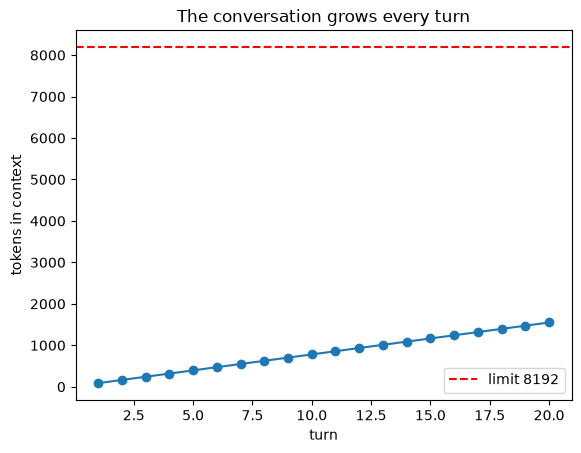

tokens at turn 20: 1550


In [13]:
import matplotlib.pyplot as plt
system = "You are a concise assistant for a retail bank."
history = [{"role": "system", "content": system}]
totals = []
for turn in range(1, 21):
    history.append({"role": "user", "content": f"Turn {turn}: {TEXTS['english']}"})
    history.append({"role": "assistant", "content": "Certainly. " + "Here is a detailed answer about your loan. " * 6})
    totals.append(sum(count_tokens(m["content"]) for m in history))
LIMIT = 8192   # a small window, for the picture; real models are far larger — but so are real conversations with documents
plt.plot(range(1, 21), totals, marker="o"); plt.axhline(LIMIT, color="red", linestyle="--", label=f"limit {LIMIT}")
plt.xlabel("turn"); plt.ylabel("tokens in context"); plt.title("The conversation grows every turn"); plt.legend(); plt.show()
print("tokens at turn 20:", totals[-1])

**Key Finding:** Unmanaged multi-turn conversations experience rapid token growth. While the 20-turn simulation reached 1,550 tokens (safely under the 8,192 limit), it proves that the developer framework—not the LLM—must actively manage, truncate, or summarize context to prevent exhaustion in extended production sessions.

## 5. Semantic Mapping via Vector Embeddings
An embedding model turns text into a high-dimensional vector. We embed ten words using a local model (`nomic-embed-text`), apply Principal Component Analysis (PCA) via NumPy to reduce the 768 dimensions down to 2, and plot them to visualize semantic proximity.

source: ollama:nomic-embed-text


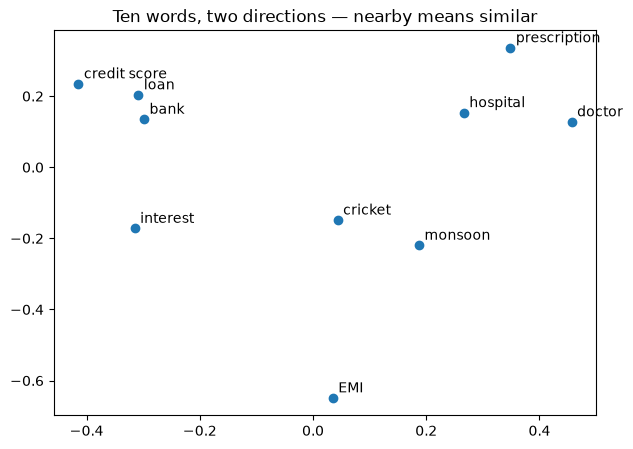

In [14]:
pts, source = load_points(WORDS)
print("source:", source)
plt.figure(figsize=(7, 5))
plt.scatter(pts[:, 0], pts[:, 1])
for w, (x, y) in zip(WORDS, pts):
    plt.annotate(w, (x, y), xytext=(4, 4), textcoords="offset points")
plt.title("Ten words, two directions — nearby means similar"); plt.show()

**Key Finding:** The PCA reduction successfully isolates distinct semantic clusters: a financial cluster ('credit score', 'loan', 'bank') and a medical cluster ('hospital', 'doctor', 'prescription'). However, ambiguous terms like 'EMI' remain isolated; without surrounding context, an embedding model maps multi-meaning tokens to a statistical middle ground rather than a precise definition.